# We load the data

We first load the data

In [1]:
from src.data.loader import load_training_data, prepare_features_target, make_train_val_split
from src.models.xgboost_model import XGBoostPDModel

df = load_training_data("src/data/GiveMeSomeCredit/cs-training.csv")
X, y = prepare_features_target(df)
X_train, X_val, y_train, y_val = make_train_val_split(X, y)

model = XGBoostPDModel()
model.fit(X_train, y_train)

metrics = model.evaluate(X_val, y_val)
metrics

{'roc_auc': 0.8640030571900308,
 'pr_auc': 0.39597653290221235,
 'log_loss': 0.4183312235245534}

In [3]:
probs_val = model.predict_proba(X_val)

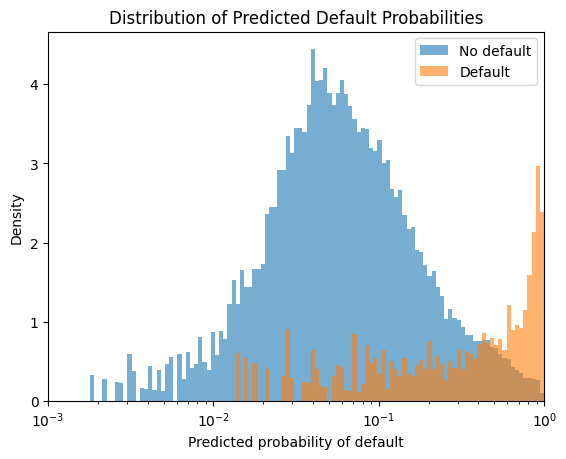

In [13]:
import matplotlib.pyplot as plt
import numpy as np

probs_default = probs_val[y_val.to_numpy().ravel() == 1]
probs_nondefault = probs_val[y_val.to_numpy().ravel() == 0]

#plt.figure(figsize=(8, 5))

#bins = np.logspace(-2, 0, 100)

bins = np.logspace(-3, 0, 120)
plt.xlim(1e-3, 1)

plt.hist(
    probs_nondefault,
    bins=bins,
    density=True,
    alpha=0.6,
    label="No default"
)

plt.hist(
    probs_default,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Default"
)

plt.xlabel("Predicted probability of default")
plt.ylabel("Density")
plt.xscale("log")
plt.xlim(1e-3, 1)
plt.title("Distribution of Predicted Default Probabilities")
plt.legend()
plt.show()